# 02 — Exploratory Data Analysis
## Vehicle Telematics Project

**What this notebook does:**
- Sensor distributions — speed, RPM, engine load, KPL, coolant temp, throttle
- Temporal patterns — median speed by hour, trip count by day of week

**Requires:** Run `01_data_cleaning.ipynb` first to generate `data/processed/clean.parquet`

**Author:** Paşan Sancak · [LinkedIn](https://linkedin.com/in/pasansancak) · [GitHub](https://github.com/pasansancak)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

df = pd.read_parquet('../data/processed/clean.parquet')
print(f'Loaded : {len(df):,} rows  |  {df["deviceID"].nunique()} vehicles')

Loaded : 3,021,632 rows  |  15 vehicles


## 1. Sensor Distributions

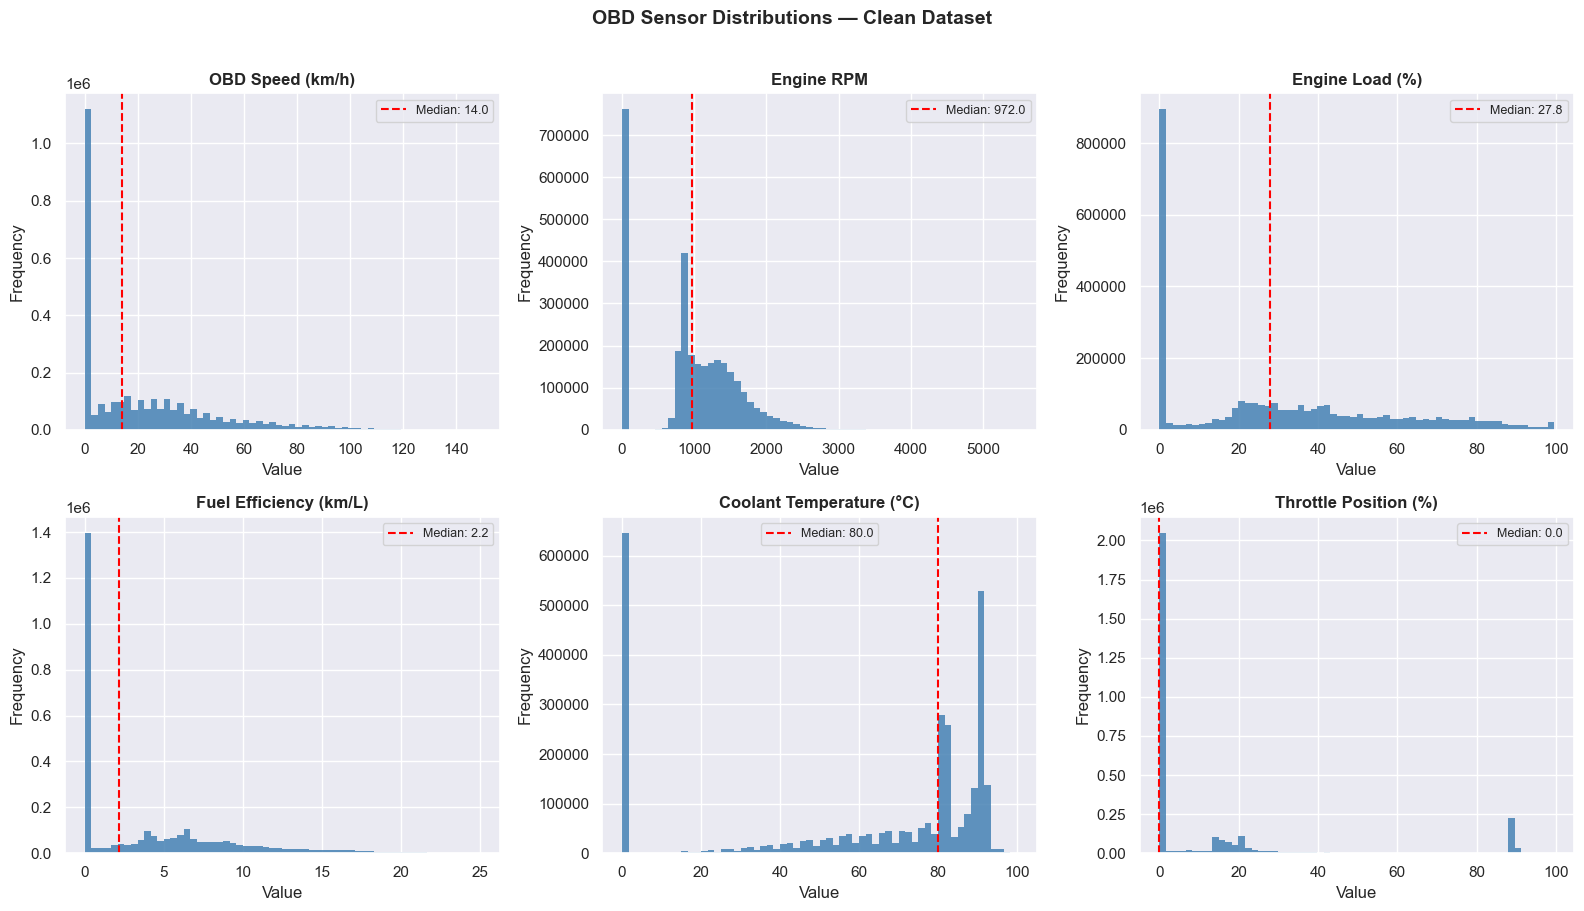

Saved -> outputs/01_sensor_distributions.png


In [2]:
plot_sensors = {k: v for k, v in {
    'speed' : 'OBD Speed (km/h)',
    'rpm'   : 'Engine RPM',
    'eLoad' : 'Engine Load (%)',
    'kpl'   : 'Fuel Efficiency (km/L)',
    'cTemp' : 'Coolant Temperature (°C)',
    'tPos'  : 'Throttle Position (%)'
}.items() if k in df.columns}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(plot_sensors.items()):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    axes[i].axvline(data.median(), color='red', linestyle='--', lw=1.5,
                    label=f'Median: {data.median():.1f}')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('OBD Sensor Distributions — Clean Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/01_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/01_sensor_distributions.png')

## 2. Temporal Patterns

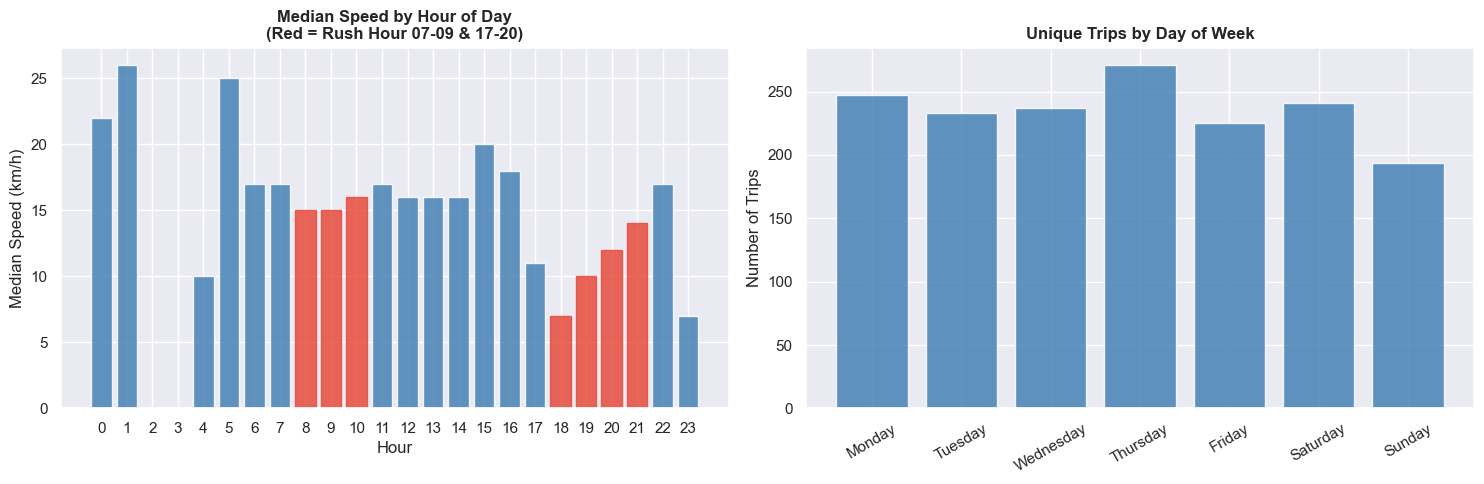

Saved -> outputs/02_temporal_patterns.png


In [3]:
df['hour']        = df['timeStamp'].dt.hour
df['day_of_week'] = df['timeStamp'].dt.day_name()

hourly = df.groupby('hour')['speed'].median()
rush   = list(range(7, 10)) + list(range(17, 21))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Median speed by hour — rush hours in red
bars = axes[0].bar(hourly.index, hourly.values, color='steelblue', alpha=0.85)
for i, bar in enumerate(bars):
    if i in rush:
        bar.set_color('#e74c3c')
axes[0].set_title('Median Speed by Hour of Day\n(Red = Rush Hour 07-09 & 17-20)', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Median Speed (km/h)')
axes[0].set_xticks(range(0, 24))

# Trip count by day of week
dow_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_counts = df.groupby('day_of_week')['tripID'].nunique().reindex(dow_order, fill_value=0)
axes[1].bar(dow_counts.index, dow_counts.values, color='steelblue', alpha=0.85)
axes[1].set_title('Unique Trips by Day of Week', fontweight='bold')
axes[1].set_ylabel('Number of Trips')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/02_temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/02_temporal_patterns.png')